# Segmentación y predicción del rendimiento académico estudiantil

No se incluye las bases de estudiantes por confidencialidad, solo se incluye la relacionada al subconjunto analitico.

## Librerias

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import statsmodels
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score, r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

SEED = 42                      # semilla única, garantiza que los resultados sean reproducibles
np.random.seed(SEED)

DATA_DIR = Path('datos')       
FIG_DIR = Path('figuras')      
FIG_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
plt.rcParams.update({'font.size': 11})

RESULTADOS = {}                


def guardar_figura(nombre):
    plt.tight_layout()
    plt.savefig(FIG_DIR / nombre, dpi=150)
    plt.show()


print('Python', sys.version.split()[0], '| pandas', pd.__version__, '| numpy', np.__version__,
      '| scikit-learn', sklearn.__version__, '| statsmodels', statsmodels.__version__,
      '| matplotlib', matplotlib.__version__)

Python 3.12.3 | pandas 3.0.2 | numpy 2.4.4 | scikit-learn 1.8.0 | statsmodels 0.15.0 | matplotlib 3.10.8


## 1. Carga de datos

Fuente: base institucional de estudiantes de los periodos 2024-01 y 2024-02 anonimizada solo se cargan las 16 columnas que el análisis necesita; el resto de las columnas del archivo no se lee.

In [2]:
RUTA_2024 = DATA_DIR / 'estudiantes_2024_completo_anonimizado.csv'
if not RUTA_2024.exists():
    raise FileNotFoundError(
        f'No se encontró {RUTA_2024}. Copia la base anonimizada en la carpeta "datos/" (ver datos/LEEME.md).')

COLUMNAS = [
    'CRÉDITOS APROBADOS', 'edad', 'SEXO', 'fuente', 'SEDE ',
    'TIPO_COLEGIO', 'POLITICA_CUOTA', 'NIVEL_FORMACION_PADRE', 'NIVEL_FORMACION_MADRE',
    'RECIBE TUTORIAS INTEGRALES (ACADÉMICAS Y DE ACOMPAÑAMIENTO)',
    'NÚMERO DE TUTORIAS ACADÉMICAS', 'NÚMERO DE TUTORIAS DE ACOMPAÑAMIENTO',
    'HA REPETIDO AL MENOS UNA MATERIA', 'NUMERO DE MATERIAS SEGUNDA MATRICULA',
    'NUMERO DE MATERIAS TERCERA MATRICULA', 'HA PERDIDO LA GRATUIDAD',
]

n_columnas_archivo = len(pd.read_csv(RUTA_2024, nrows=0).columns)
df = pd.read_csv(RUTA_2024, usecols=COLUMNAS, low_memory=False)

print(f'Registros: {len(df):,} | columnas en el archivo: {n_columnas_archivo} | columnas cargadas: {df.shape[1]}')
print('\nRegistros por periodo:')
print(df['fuente'].value_counts().sort_index())

Registros: 49,005 | columnas en el archivo: 59 | columnas cargadas: 16

Registros por periodo:
fuente
2024-01    23743
2024-02    25262
Name: count, dtype: int64


## 2. Depuración y transformación de variables
### 2.1. Créditos aprobados: filtrado de valores atípicos

La variable `CRÉDITOS APROBADOS` contiene valores atípicos para un periodo académico.

In [3]:
col_credit = 'CRÉDITOS APROBADOS'
df[col_credit] = pd.to_numeric(df[col_credit], errors='coerce')

n_inicial = len(df)
n_con_valor = int(df[col_credit].notna().sum())
n_fuera = int(((df[col_credit] < 0) | (df[col_credit] > 60)).sum())
n_mas_200 = int((df[col_credit] > 200).sum())

print(f'Registros iniciales:                          {n_inicial:,}')
print(f'Con valor numérico en créditos aprobados:     {n_con_valor:,} ({100 * n_con_valor / n_inicial:.1f}%)')
print(f'Fuera del rango plausible 0-60:               {n_fuera:,} ({100 * n_fuera / n_con_valor:.1f}% de los que tienen valor)')
print(f'   de ellos, con más de 200 créditos:         {n_mas_200:,} ({100 * n_mas_200 / n_con_valor:.1f}% de los que tienen valor)')
print(f'   valor máximo observado:                    {df[col_credit].max():,.0f}')

df = df[(df[col_credit] >= 0) & (df[col_credit] <= 60)].copy()
n_tras_creditos = len(df)
print(f'\nRegistros tras el filtro de créditos:         {n_tras_creditos:,}')

Registros iniciales:                          49,005
Con valor numérico en créditos aprobados:     46,591 (95.1%)
Fuera del rango plausible 0-60:               4,563 (9.8% de los que tienen valor)
   de ellos, con más de 200 créditos:         3,604 (7.7% de los que tienen valor)
   valor máximo observado:                    54,164

Registros tras el filtro de créditos:         42,028


### 2.2. Edad: filtrado de valores atípicos

Se conserva el rango de 15 a 65 años, los valores nulos o fuera de rango se excluyen.

In [4]:
df['edad'] = pd.to_numeric(df['edad'], errors='coerce')
n_edad_nula = int(df['edad'].isna().sum())
n_menor_15 = int((df['edad'] < 15).sum())
n_mayor_65 = int((df['edad'] > 65).sum())

df = df[(df['edad'] >= 15) & (df['edad'] <= 65)].copy()
n_tras_edad = len(df)

print(f'Edad nula o no numérica: {n_edad_nula} | menor de 15 años: {n_menor_15} | mayor de 65 años: {n_mayor_65}')
print(f'Registros eliminados por edad: {n_edad_nula + n_menor_15 + n_mayor_65}')
print(f'Registros tras el filtro de edad: {n_tras_edad:,}')

Edad nula o no numérica: 43 | menor de 15 años: 82 | mayor de 65 años: 29
Registros eliminados por edad: 154
Registros tras el filtro de edad: 41,874


### 2.3. Eliminación de variables sin capacidad explicativa

`HA PERDIDO LA GRATUIDAD` tiene varianza cero, por lo que no permite distinguir entre estudiantes y se excluye del subconjunto analítico.

In [5]:
col_grat = 'HA PERDIDO LA GRATUIDAD'
print(df[col_grat].value_counts(dropna=False))
print(f'\nValores distintos: {df[col_grat].nunique(dropna=False)} -> varianza cero; se excluye del análisis.')

HA PERDIDO LA GRATUIDAD
NO    41874
Name: count, dtype: int64

Valores distintos: 1 -> varianza cero; se excluye del análisis.


### 2.4. Codificación de variables categóricas

- Instrucción de los padres: escala ordinal de 0 («no registra») a 9 («PhD»).
- Tipo de colegio: escala ordinal de 1 (fiscal) a 4 (particular); «no registra» queda como dato faltante.
- Política de cuota, sede y periodo: codificación numérica de categorías nominales.

Los códigos de las variables nominales identifican categorías y no representan un orden.

In [6]:
mapa_padres = {
    'NO REGISTRA': 0, 'EDUCACIÓN BÁSICA': 1, 'EDUCACIÓN MEDIA': 2,
    'SUPERIOR NO UNIVERSITARIA INCOMPLETA': 3, 'SUPERIOR NO UNIVERSITARIA COMPLETA': 4,
    'SUPERIOR UNIVERSITARIA INCOMPLETA': 5, 'SUPERIOR UNIVERSITARIA COMPLETA': 6,
    'ESPECIALIDAD': 7, 'POSGRADO ESPECIALIDAD ÁREA SALUD': 7,
    'POSGRADO MAESTRÍA': 8, 'POSGRADO PHD': 9,
}
mapa_colegio = {'FISCAL': 1, 'FISCOMISIONAL': 2, 'MUNICIPAL': 3, 'PARTICULAR': 4, 'NO REGISTRA': np.nan}

df['nivel_form_padre_cod'] = df['NIVEL_FORMACION_PADRE'].map(mapa_padres)
df['nivel_form_madre_cod'] = df['NIVEL_FORMACION_MADRE'].map(mapa_padres)
df['tipo_colegio_cod'] = df['TIPO_COLEGIO'].map(mapa_colegio)
df['politica_cuota_cod'] = df['POLITICA_CUOTA'].astype('category').cat.codes.replace(-1, np.nan)
df['sede_cod'] = df['SEDE '].astype('category').cat.codes.replace(-1, np.nan)
df['periodo_cod'] = df['fuente'].astype('category').cat.codes.replace(-1, np.nan)

print('Periodo -> código:')
print(df[['fuente', 'periodo_cod']].drop_duplicates().sort_values('periodo_cod').to_string(index=False))

Periodo -> código:
 fuente  periodo_cod
2024-01            0
2024-02            1


### 2.5. Variables binarias y numéricas

In [7]:
df['recibe_tutorias'] = (df['RECIBE TUTORIAS INTEGRALES (ACADÉMICAS Y DE ACOMPAÑAMIENTO)'] == 'SI').astype(int)
df['sexo_masculino'] = df['SEXO'].astype(str).str.upper().str.startswith('M').astype(int)
df['ha_repetido_materia'] = (df['HA REPETIDO AL MENOS UNA MATERIA'].astype(str).str.upper() == 'SI').astype(int)

df['num_tutorias_academicas'] = pd.to_numeric(df['NÚMERO DE TUTORIAS ACADÉMICAS'], errors='coerce')
df['num_tutorias_acompanamiento'] = pd.to_numeric(df['NÚMERO DE TUTORIAS DE ACOMPAÑAMIENTO'], errors='coerce')
df['num_materias_2da_matricula'] = pd.to_numeric(df['NUMERO DE MATERIAS SEGUNDA MATRICULA'], errors='coerce')
df['num_materias_3ra_matricula'] = pd.to_numeric(df['NUMERO DE MATERIAS TERCERA MATRICULA'], errors='coerce')
print('Variables binarias y numéricas construidas.')

Variables binarias y numéricas construidas.


### 2.6. Registro de la depuración

In [8]:
registro = pd.DataFrame({
    'Paso': ['Registros iniciales', 'Con valor numérico en créditos', 'Tras filtro de créditos (0-60)',
             'Tras filtro de edad (15-65) = subconjunto analítico'],
    'Registros': [n_inicial, n_con_valor, n_tras_creditos, n_tras_edad],
})
registro['% del inicial'] = (100 * registro['Registros'] / n_inicial).round(1)
display(registro)

RESULTADOS.update(n_inicial=n_inicial, n_tras_creditos=n_tras_creditos, n_tras_edad=n_tras_edad)

,Paso,Registros,% del inicial
0,Registros iniciales,49005,100.0
1,Con valor numérico en créditos,46591,95.1
2,Tras filtro de créditos (0-60),42028,85.8
3,Tras filtro de edad (15-65) = subconjunto anal...,41874,85.4


## 3. Subconjunto analítico (informe 7.3)

Quince variables: la dependiente (`creditos_aprobados`) y catorce independientes o de control, todas numéricas
o codificadas numéricamente.

In [9]:
analitico = pd.DataFrame({
    'creditos_aprobados': df[col_credit],
    'edad': df['edad'],
    'num_tutorias_academicas': df['num_tutorias_academicas'],
    'num_tutorias_acompanamiento': df['num_tutorias_acompanamiento'],
    'num_materias_2da_matricula': df['num_materias_2da_matricula'],
    'num_materias_3ra_matricula': df['num_materias_3ra_matricula'],
    'recibe_tutorias': df['recibe_tutorias'],
    'sexo_masculino': df['sexo_masculino'],
    'ha_repetido_materia': df['ha_repetido_materia'],
    'tipo_colegio_cod': df['tipo_colegio_cod'],
    'politica_cuota_cod': df['politica_cuota_cod'],
    'sede_cod': df['sede_cod'],
    'periodo_cod': df['periodo_cod'],
    'nivel_form_padre_cod': df['nivel_form_padre_cod'],
    'nivel_form_madre_cod': df['nivel_form_madre_cod'],
})
print(f'Subconjunto analítico: {analitico.shape[0]:,} registros x {analitico.shape[1]} variables')

Subconjunto analítico: 41,874 registros x 15 variables


## 4. Estadísticas descriptivas (informe 7.3 y 7.4)

In [10]:
display(analitico.describe().round(2).T)

pct_cero = (analitico['creditos_aprobados'] == 0).mean() * 100
RESULTADOS['pct_cero'] = pct_cero
print(f'\nRegistros con 0 créditos aprobados en el periodo: {pct_cero:.1f}%')

print('\n--- Datos faltantes en las variables socioeconómicas (% de registros) ---')
faltantes = analitico[['tipo_colegio_cod', 'politica_cuota_cod', 'nivel_form_padre_cod', 'nivel_form_madre_cod']].isna().mean() * 100
print(faltantes.round(1).to_string())

,count,mean,std,min,25%,50%,75%,max
creditos_aprobados,41874.0,10.80,12.66,0.0,0.0,9.0,18.0,60.0
edad,41874.0,23.43,5.77,15.0,20.0,22.0,25.0,65.0
num_tutorias_academicas,41267.0,1.51,3.05,0.0,0.0,0.0,2.0,35.0
num_tutorias_acompanamiento,41267.0,0.51,1.75,0.0,0.0,0.0,0.0,33.0
num_materias_2da_matricula,41874.0,0.15,0.63,0.0,0.0,0.0,0.0,21.0
num_materias_3ra_matricula,41874.0,0.02,0.20,0.0,0.0,0.0,0.0,16.0
recibe_tutorias,41874.0,0.42,0.49,0.0,0.0,0.0,1.0,1.0
sexo_masculino,41874.0,0.55,0.50,0.0,0.0,1.0,1.0,1.0
ha_repetido_materia,41874.0,0.12,0.33,0.0,0.0,0.0,0.0,1.0
tipo_colegio_cod,29599.0,2.70,1.37,1.0,1.0,4.0,4.0,4.0



Registros con 0 créditos aprobados en el periodo: 46.7%

--- Datos faltantes en las variables socioeconómicas (% de registros) ---
tipo_colegio_cod        29.3
politica_cuota_cod      40.3
nivel_form_padre_cod    18.0
nivel_form_madre_cod    20.2


In [11]:
print('--- Créditos aprobados promedio según tutorías ---')
print(analitico.groupby('recibe_tutorias')['creditos_aprobados'].mean().round(1).to_string())

print('\n--- Créditos aprobados promedio por periodo ---')
print(df.groupby('fuente')[col_credit].mean().round(1).to_string())

print('\n--- Distribución por sexo (% de registros) ---')
print((analitico['sexo_masculino'].value_counts(normalize=True) * 100).round(1).rename({1: 'masculino', 0: 'femenino'}).to_string())

print('\n--- Repitencia ---')
print(f"Registros con al menos una materia repetida: {analitico['ha_repetido_materia'].mean() * 100:.1f}%")
print(analitico.groupby('ha_repetido_materia')['creditos_aprobados'].mean().round(1).rename({0: 'no repitió', 1: 'repitió'}).to_string())

print('\n--- Materias en segunda y tercera matrícula (% de registros con al menos una) ---')
print(f"Segunda matrícula: {(analitico['num_materias_2da_matricula'] > 0).mean() * 100:.1f}% | "
      f"Tercera matrícula: {(analitico['num_materias_3ra_matricula'] > 0).mean() * 100:.1f}%")

print('\n--- Sede: registros y créditos promedio ---')
sede = df.groupby('SEDE ')[col_credit].agg(registros='size', creditos_prom='mean').round(1).sort_values('creditos_prom')
display(sede)

--- Créditos aprobados promedio según tutorías ---
recibe_tutorias
0     8.6
1    13.9

--- Créditos aprobados promedio por periodo ---


fuente
2024-01    19.6
2024-02     3.4

--- Distribución por sexo (% de registros) ---
sexo_masculino
masculino    55.4
femenino     44.6

--- Repitencia ---
Registros con al menos una materia repetida: 12.5%
ha_repetido_materia
no repitió     9.5
repitió       19.8

--- Materias en segunda y tercera matrícula (% de registros con al menos una) ---
Segunda matrícula: 8.6% | Tercera matrícula: 1.4%

--- Sede: registros y créditos promedio ---


,registros,creditos_prom
SEDE,,
Sede D,607,0.2
Sede E,24035,9.2
Sede F,3975,10.2
Sede B,3644,10.4
Sede C,4612,15.8
Sede A,5001,15.9


## 5. Matriz de correlación

Correlación de Pearson entre las 15 variables

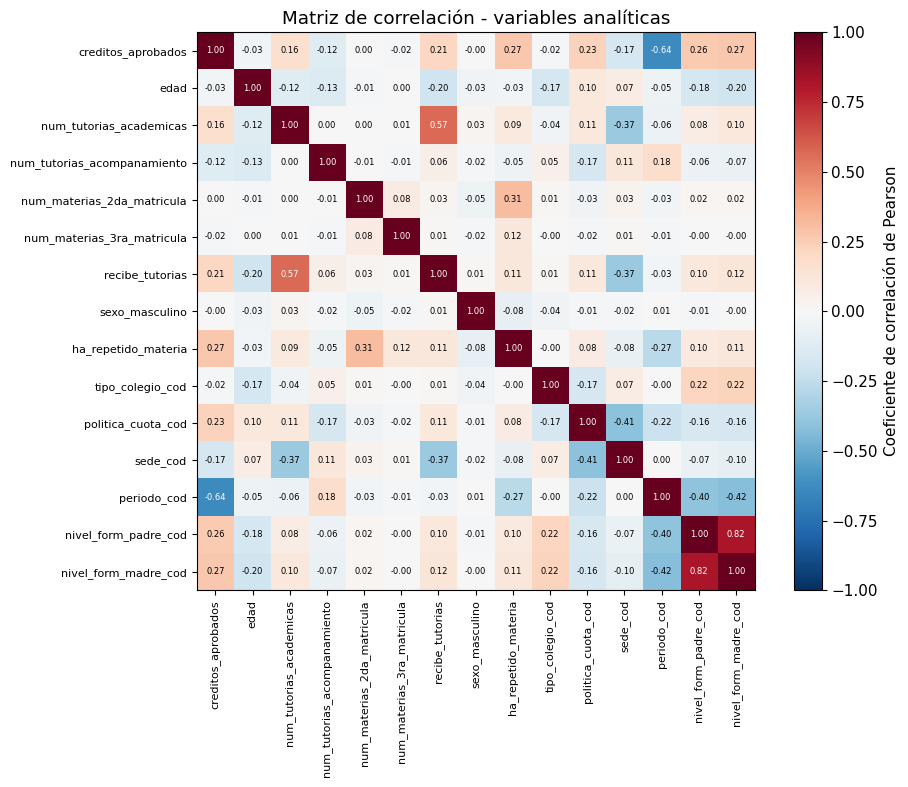

Correlación de cada variable con los créditos aprobados (ordenadas por magnitud):
periodo_cod                   -0.64
nivel_form_madre_cod           0.27
ha_repetido_materia            0.27
nivel_form_padre_cod           0.26
politica_cuota_cod             0.23
recibe_tutorias                0.21
sede_cod                      -0.17
num_tutorias_academicas        0.16
num_tutorias_acompanamiento   -0.12
edad                          -0.03
tipo_colegio_cod              -0.02
num_materias_3ra_matricula    -0.02
num_materias_2da_matricula     0.00
sexo_masculino                -0.00

Instrucción padre-madre: r = 0.82
Recibe tutorías - número de tutorías académicas: r = 0.57


In [12]:
corr = analitico.corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6, color='white' if abs(v) > 0.5 else 'black')
plt.colorbar(im, ax=ax, label='Coeficiente de correlación de Pearson')
ax.set_title('Matriz de correlación - variables analíticas')
guardar_figura('figura1_matriz_correlacion.png')

print('Correlación de cada variable con los créditos aprobados (ordenadas por magnitud):')
print(corr['creditos_aprobados'].drop('creditos_aprobados').reindex(
    corr['creditos_aprobados'].drop('creditos_aprobados').abs().sort_values(ascending=False).index).round(2).to_string())
print(f"\nInstrucción padre-madre: r = {corr.loc['nivel_form_padre_cod', 'nivel_form_madre_cod']:.2f}")
print(f"Recibe tutorías - número de tutorías académicas: r = {corr.loc['recibe_tutorias', 'num_tutorias_academicas']:.2f}")

El periodo es la variable más asociada a los créditos aprobados (el periodo 2024-02 corresponde a un
corte tomado en otro momento del calendario académico, por lo que se usa como variable de control). La
instrucción del padre y de la madre están muy correlacionadas entre sí.

## 6. Visualización de variables de interés

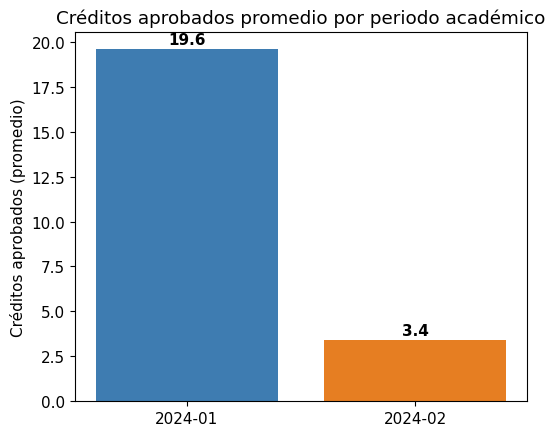

In [13]:
# Figura 2. Créditos aprobados promedio por periodo
prom_periodo = df.groupby('fuente')[col_credit].mean()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.bar(prom_periodo.index, prom_periodo.values, color=['#3E7CB1', '#E67E22'])
ax.set_title('Créditos aprobados promedio por periodo académico')
ax.set_ylabel('Créditos aprobados (promedio)')
for i, v in enumerate(prom_periodo.values):
    ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
guardar_figura('figura2_creditos_por_periodo.png')

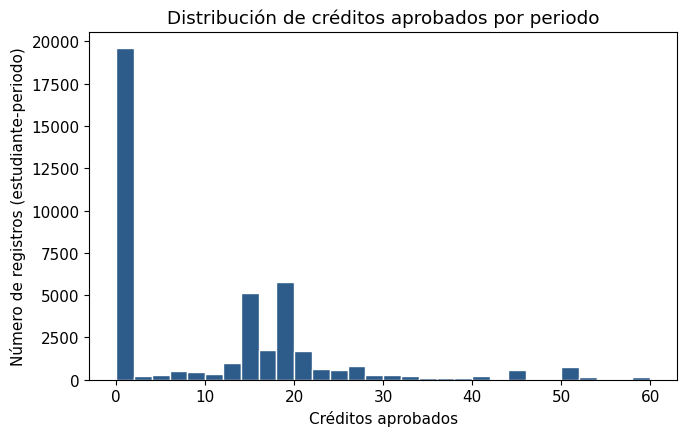

In [14]:
# Figura 3. Distribución de créditos aprobados
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(analitico['creditos_aprobados'].dropna(), bins=30, color='#2E5C8A', edgecolor='white')
ax.set_title('Distribución de créditos aprobados por periodo')
ax.set_xlabel('Créditos aprobados')
ax.set_ylabel('Número de registros (estudiante-periodo)')
guardar_figura('figura3_distribucion_creditos.png')

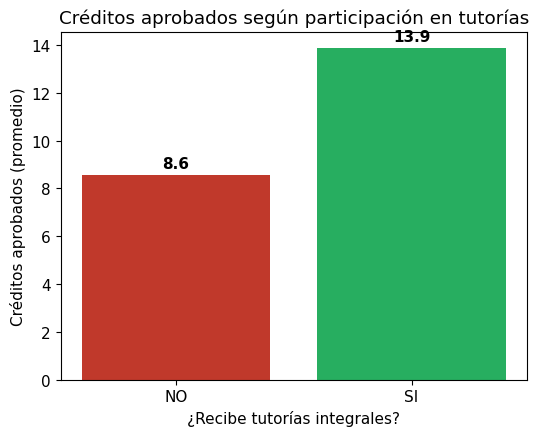

In [15]:
# Figura 4. Créditos aprobados según participación en tutorías
prom_tut = analitico.groupby('recibe_tutorias')['creditos_aprobados'].mean()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.bar(['NO', 'SI'], prom_tut.values, color=['#C0392B', '#27AE60'])
ax.set_title('Créditos aprobados según participación en tutorías')
ax.set_ylabel('Créditos aprobados (promedio)')
ax.set_xlabel('¿Recibe tutorías integrales?')
for i, v in enumerate(prom_tut.values):
    ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
guardar_figura('figura4_creditos_tutorias.png')

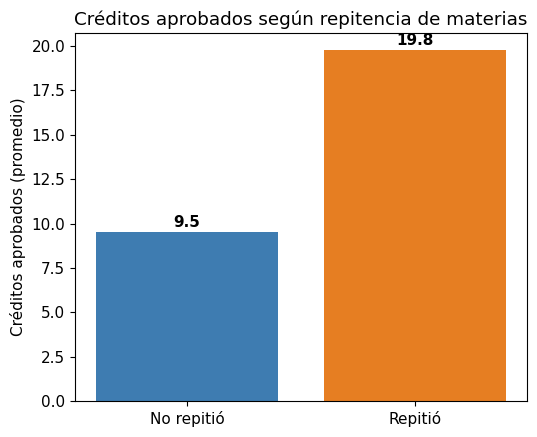

In [16]:
# Figura 5. Créditos aprobados según repitencia de materias
prom_rep = analitico.groupby('ha_repetido_materia')['creditos_aprobados'].mean()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.bar(['No repitió', 'Repitió'], prom_rep.values, color=['#3E7CB1', '#E67E22'])
ax.set_title('Créditos aprobados según repitencia de materias')
ax.set_ylabel('Créditos aprobados (promedio)')
for i, v in enumerate(prom_rep.values):
    ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
guardar_figura('figura5_creditos_repitencia.png')

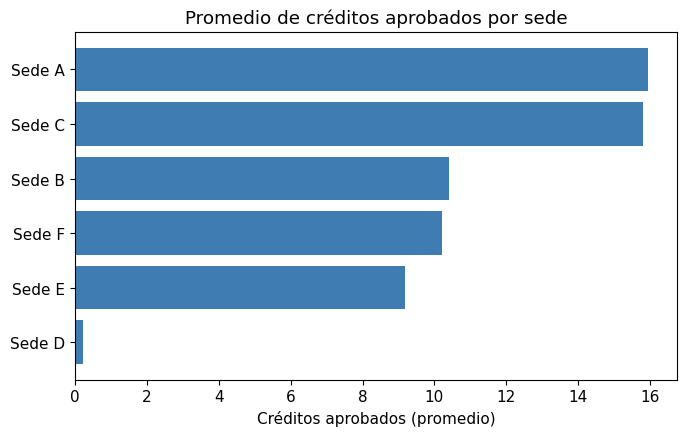

In [17]:
# Figura 6. Créditos aprobados promedio por sede
prom_sede = df.groupby('SEDE ')[col_credit].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(prom_sede.index, prom_sede.values, color='#3E7CB1')
ax.set_title('Promedio de créditos aprobados por sede')
ax.set_xlabel('Créditos aprobados (promedio)')
guardar_figura('figura6_creditos_por_sede.png')

## 7. Guardado del subconjunto analítico

Se guarda el subconjunto limpio y codificado como subconjunto_analitico

In [18]:
analitico.to_csv(DATA_DIR / 'subconjunto_analitico.csv', index=False)
print(f'Guardado: datos/subconjunto_analitico.csv ({analitico.shape[0]:,} filas x {analitico.shape[1]} columnas)')

Guardado: datos/subconjunto_analitico.csv (41,874 filas x 15 columnas)


## 8. Índice de instrucción de los padres y casos completos

La instrucción del padre y de la madre se combina en un índice. Cuando solo se conoce la instrucción de uno de los dos, el promedio usa el dato disponible, lo que conserva esos registros.

Los modelos se estiman con casos completos: registros con información en todas las variables del modelo.
No se imputan valores faltantes, porque la institución no registró esos datos y imputarlos exigiría supuestos
difíciles de justificar. Esta decisión reduce la muestra y es una limitación del estudio.

In [19]:
analitico['indice_instruccion_padres'] = analitico[['nivel_form_padre_cod', 'nivel_form_madre_cod']].mean(axis=1)

cluster_vars = ['tipo_colegio_cod', 'politica_cuota_cod', 'indice_instruccion_padres', 'recibe_tutorias', 'sede_cod']
reg_vars = ['tipo_colegio_cod', 'politica_cuota_cod', 'indice_instruccion_padres', 'recibe_tutorias',
            'sexo_masculino', 'edad', 'sede_cod', 'periodo_cod']

print('% de registros con dato faltante en las variables de la segmentación:')
print((analitico[cluster_vars].isna().mean() * 100).round(1).to_string())

data_cluster = analitico.dropna(subset=cluster_vars).copy()
data_reg = analitico.dropna(subset=reg_vars + ['creditos_aprobados']).copy()
print(f'\nCasos completos para la segmentación: {len(data_cluster):,} ({100 * len(data_cluster) / len(analitico):.1f}% del subconjunto)')
print(f'Casos completos para la predicción:   {len(data_reg):,} ({100 * len(data_reg) / len(analitico):.1f}% del subconjunto)')
RESULTADOS['n_casos_completos'] = len(data_cluster)

% de registros con dato faltante en las variables de la segmentación:
tipo_colegio_cod             29.3
politica_cuota_cod           40.3
indice_instruccion_padres    17.5
recibe_tutorias               0.0
sede_cod                      0.0

Casos completos para la segmentación: 13,695 (32.7% del subconjunto)
Casos completos para la predicción:   13,695 (32.7% del subconjunto)


## 9. Segmentación: K-means vs. clustering jerárquico

K-means agrupa observaciones minimizando la suma de distancias cuadráticas al centroide de cada grupo.
Las variables se estandarizan para que ninguna domine el cálculo de distancias, y los créditos aprobados no
participan en la construcción de los grupos, así el rendimiento queda como variable externa de validación.

### 9.1. Método del codo y coeficiente de silueta

,k,inercia,silueta
0,2,51316.135,0.284
1,3,39420.490,0.286
2,4,32873.658,0.300
3,5,28724.445,0.317
4,6,25894.513,0.331
5,7,23075.401,0.345


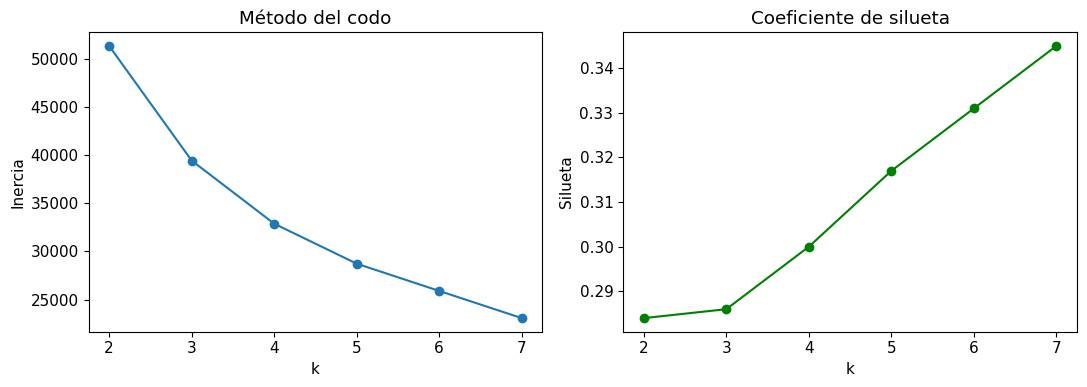

In [20]:
X_cluster = StandardScaler().fit_transform(data_cluster[cluster_vars])

filas = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    etiquetas = km.fit_predict(X_cluster)
    filas.append((k, km.inertia_, silhouette_score(X_cluster, etiquetas)))
tabla_k = pd.DataFrame(filas, columns=['k', 'inercia', 'silueta']).round(3)
display(tabla_k)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tabla_k['k'], tabla_k['inercia'], marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[1].plot(tabla_k['k'], tabla_k['silueta'], marker='o', color='green')
axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silueta')
guardar_figura('figura_complementaria_codo_silueta.png')

**Selección de k.** En este rango la silueta crece de forma continua con k, algo habitual con variables
categóricas de baja cardinalidad y no marca un máximo claro. Se eligió k = 4 combinando dos criterios, la caída de
la inercia se desacelera  después de k = 4.

### 9.2. K-means (k = 4) frente al clustering jerárquico

In [21]:
K = 4
km_final = KMeans(n_clusters=K, random_state=SEED, n_init=10)
etiquetas_raw = km_final.fit_predict(X_cluster)
silueta_km = silhouette_score(X_cluster, etiquetas_raw)

agg = AgglomerativeClustering(n_clusters=K)      # clustering jerárquico aglomerativo (Ward)
etiquetas_agg = agg.fit_predict(X_cluster)
silueta_agg = silhouette_score(X_cluster, etiquetas_agg)

print(f'K-means      (k={K}) -> silueta = {silueta_km:.3f}')
print(f'Jerárquico   (k={K}) -> silueta = {silueta_agg:.3f}')
print('->', 'K-means obtiene mejor cohesión y separación.' if silueta_km > silueta_agg else 'El jerárquico obtiene mejor cohesión y separación.')
RESULTADOS.update(silueta_km=silueta_km, silueta_agg=silueta_agg)

K-means      (k=4) -> silueta = 0.300
Jerárquico   (k=4) -> silueta = 0.271
-> K-means obtiene mejor cohesión y separación.


### 9.3. Perfil de los clústeres

Las etiquetas se ordenan por rendimiento, el clúster 0 es el de mayor promedio de créditos aprobados y el
clúster 3 el de menor. Así la numeración es reproducible, sin depender del orden interno de K-means.

In [22]:
promedios = pd.Series(data_cluster['creditos_aprobados'].values).groupby(etiquetas_raw).mean()
orden = promedios.sort_values(ascending=False).index
mapa_etiquetas = {viejo: nuevo for nuevo, viejo in enumerate(orden)}
data_cluster['cluster'] = pd.Series(etiquetas_raw, index=data_cluster.index).map(mapa_etiquetas)

perfil = data_cluster.groupby('cluster').agg(
    n=('creditos_aprobados', 'size'),
    creditos_prom=('creditos_aprobados', 'mean'),
    tipo_colegio=('tipo_colegio_cod', 'mean'),
    politica_cuota=('politica_cuota_cod', 'mean'),
    instruccion_padres=('indice_instruccion_padres', 'mean'),
    pct_tutorias=('recibe_tutorias', 'mean'),
)
perfil['pct_tutorias'] = (perfil['pct_tutorias'] * 100).round(1)
perfil = perfil.round(2)
display(perfil)

print(f"Diferencia de créditos entre el mejor y el peor clúster: {perfil['creditos_prom'].max() - perfil['creditos_prom'].min():.2f}")
print(f"Brecha de cobertura de tutorías entre el clúster 1 y el clúster 2: "
      f"{perfil.loc[1, 'pct_tutorias'] - perfil.loc[2, 'pct_tutorias']:.1f} puntos porcentuales "
      f"({perfil.loc[1, 'pct_tutorias']:.1f}% frente a {perfil.loc[2, 'pct_tutorias']:.1f}%)")

,n,creditos_prom,tipo_colegio,politica_cuota,instruccion_padres,pct_tutorias
cluster,,,,,,
0,3263,21.72,3.51,0.19,5.41,45.7
1,3317,21.08,2.46,1.18,2.86,85.8
2,3834,20.43,1.19,0.77,0.55,22.4
3,3281,18.17,3.92,0.69,0.42,31.5


Diferencia de créditos entre el mejor y el peor clúster: 3.55
Brecha de cobertura de tutorías entre el clúster 1 y el clúster 2: 63.4 puntos porcentuales (85.8% frente a 22.4%)


## 10. Predicción: regresión lineal múltiple vs. Random Forest

Ambos modelos se entrenan con el 80% de los registros y se evalúan con el 20% restante. Todas las métricas se calculan sobre ese conjunto de prueba.

In [23]:
X = data_reg[reg_vars]
y = data_reg['creditos_aprobados']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f'Entrenamiento: {len(X_train):,} registros | Prueba: {len(X_test):,} registros')


def metricas(real, pred):
    return {'R2': r2_score(real, pred),
            'RMSE': float(np.sqrt(mean_squared_error(real, pred))),
            'MAE': mean_absolute_error(real, pred)}


lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED).fit(X_train, y_train)

m_lr = metricas(y_test, lr.predict(X_test))
m_rf = metricas(y_test, rf.predict(X_test))

comparacion = pd.DataFrame({'Regresión lineal múltiple': m_lr, 'Random Forest (200 árboles)': m_rf}).T.round(3)
display(comparacion)

mae_base = float((y - y.mean()).abs().mean())
print(f'Referencia: predecir siempre el promedio general ({y.mean():.2f} créditos) da un MAE de {mae_base:.2f}.')
print(f'Reducción del MAE de Random Forest frente a esa referencia: {100 * (mae_base - m_rf["MAE"]) / mae_base:.0f}%')
print(f'Reducción del MAE de Random Forest frente a la regresión lineal: {100 * (m_lr["MAE"] - m_rf["MAE"]) / m_lr["MAE"]:.0f}%')

RESULTADOS.update(r2_lr=m_lr['R2'], rmse_lr=m_lr['RMSE'], mae_lr=m_lr['MAE'],
                  r2_rf=m_rf['R2'], rmse_rf=m_rf['RMSE'], mae_rf=m_rf['MAE'])

Entrenamiento: 10,956 registros | Prueba: 2,739 registros


,R2,RMSE,MAE
Regresión lineal múltiple,0.215,10.917,7.807
Random Forest (200 árboles),0.417,9.404,6.073


Referencia: predecir siempre el promedio general (20.36 créditos) da un MAE de 8.43.
Reducción del MAE de Random Forest frente a esa referencia: 28%
Reducción del MAE de Random Forest frente a la regresión lineal: 22%


### 10.1. Regresión lineal: coeficientes


In [24]:
coefs = pd.Series(lr.coef_, index=reg_vars).round(3)
print(coefs.to_string())
print(f'Intercepto: {lr.intercept_:.3f}')

tipo_colegio_cod             -0.347
politica_cuota_cod            1.349
indice_instruccion_padres    -0.343
recibe_tutorias               4.498
sexo_masculino                0.297
edad                         -0.059
sede_cod                      0.768
periodo_cod                 -19.928
Intercepto: 19.152


El coeficiente de `indice_instruccion_padres` es negativo, a diferencia de su correlación simple
positiva con los créditos. 

### 10.2. Random Forest: importancia de las variables


Periodo académico            32.5
Sede                         18.0
Edad                         16.4
Instrucción de los padres    14.1
Política de cuota             9.0
Recibe tutorías               4.1
Tipo de colegio               3.6
Sexo                          2.4


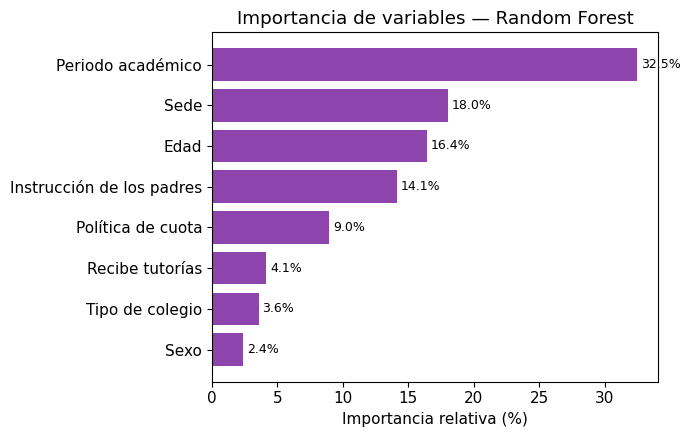

In [25]:
nombres_vars = {
    'periodo_cod': 'Periodo académico', 'sede_cod': 'Sede', 'edad': 'Edad',
    'indice_instruccion_padres': 'Instrucción de los padres', 'politica_cuota_cod': 'Política de cuota',
    'recibe_tutorias': 'Recibe tutorías', 'tipo_colegio_cod': 'Tipo de colegio', 'sexo_masculino': 'Sexo',
}
importancia = pd.Series(rf.feature_importances_, index=reg_vars).sort_values(ascending=False)
print((importancia * 100).round(1).rename(nombres_vars).to_string())

imp_plot = importancia.sort_values().rename(nombres_vars)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp_plot.index, imp_plot.values * 100, color='#8E44AD')
ax.set_title('Importancia de variables — Random Forest')
ax.set_xlabel('Importancia relativa (%)')
for i, v in enumerate(imp_plot.values * 100):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
guardar_figura('figura8_importancia_variables_rf.png')

RESULTADOS['imp_periodo'] = float(importancia['periodo_cod'] * 100)

Random Forest predice mejor que la regresión lineal (mayor R², menor error)
y se adopta como modelo predictivo final. 

## 11. Multicolinealidad: factor de inflación de la varianza, VIF 

El VIF mide cuánto se infla la varianza del coeficiente de una variable por estar correlacionada con las demás.
Como referencia, un VIF superior a 5 sugiere un problema de multicolinealidad. Se calcula para el modelo con la instrucción del padre y de la madre por separado y para el modelo con el índice combinado.

In [26]:
def tabla_vif(datos, variables):
    # Se agrega el intercepto: es la forma estándar de calcular el VIF y evita que el resultado
    # dependa de la versión de statsmodels (algunas versiones lo calculan sin intercepto).
    A = add_constant(datos[variables], has_constant='add').values.astype(float)
    return pd.Series([variance_inflation_factor(A, i + 1) for i in range(len(variables))], index=variables).round(2)


vars_separadas = ['tipo_colegio_cod', 'politica_cuota_cod', 'nivel_form_padre_cod', 'nivel_form_madre_cod',
                  'recibe_tutorias', 'sexo_masculino', 'edad', 'sede_cod', 'periodo_cod']
vars_indice = ['tipo_colegio_cod', 'politica_cuota_cod', 'indice_instruccion_padres',
               'recibe_tutorias', 'sexo_masculino', 'edad', 'sede_cod', 'periodo_cod']

vif_sep = tabla_vif(analitico.dropna(subset=vars_separadas), vars_separadas)
vif_ind = tabla_vif(analitico.dropna(subset=vars_indice), vars_indice)

print('VIF con padre y madre por separado:')
print(vif_sep.to_string())
print('\nVIF con el índice combinado:')
print(vif_ind.to_string())
print(f'\nVIF máximo: {max(vif_sep.max(), vif_ind.max()):.2f} (umbral de referencia: 5)')

RESULTADOS.update(vif_padre=float(vif_sep['nivel_form_padre_cod']), vif_madre=float(vif_sep['nivel_form_madre_cod']))

VIF con padre y madre por separado:
tipo_colegio_cod        1.12
politica_cuota_cod      1.40
nivel_form_padre_cod    2.25
nivel_form_madre_cod    2.39
recibe_tutorias         1.24
sexo_masculino          1.00
edad                    1.15
sede_cod                1.48
periodo_cod             1.10

VIF con el índice combinado:
tipo_colegio_cod             1.12
politica_cuota_cod           1.41
indice_instruccion_padres    1.41
recibe_tutorias              1.23
sexo_masculino               1.00
edad                         1.14
sede_cod                     1.48
periodo_cod                  1.15

VIF máximo: 2.39 (umbral de referencia: 5)


Ningún VIF supera 5, por lo que la multicolinealidad entre la instrucción del padre y de la madre
(r = 0.82) no es severa. 

## 12. Índice combinado vs. variables separadas 

In [27]:
def evaluar_regresion(variables):
    datos = analitico.dropna(subset=variables + ['creditos_aprobados'])
    Xv, yv = datos[variables], datos['creditos_aprobados']
    Xtr, Xte, ytr, yte = train_test_split(Xv, yv, test_size=0.2, random_state=SEED)
    modelo = LinearRegression().fit(Xtr, ytr)
    return len(datos), metricas(yte, modelo.predict(Xte)), pd.Series(modelo.coef_, index=variables)


n_ind, m_ind, _ = evaluar_regresion(vars_indice)
n_sep, m_sep, coef_sep = evaluar_regresion(vars_separadas)

display(pd.DataFrame({
    'Índice combinado': {'Registros': n_ind, 'R2': m_ind['R2'], 'RMSE': m_ind['RMSE']},
    'Padre y madre separados': {'Registros': n_sep, 'R2': m_sep['R2'], 'RMSE': m_sep['RMSE']},
}).round(3))
print('Coeficientes de la instrucción con las variables separadas:')
print(coef_sep[['nivel_form_padre_cod', 'nivel_form_madre_cod']].round(3).to_string())

,Índice combinado,Padre y madre separados
Registros,13695.000,13128.000
R2,0.215,0.149
RMSE,10.917,11.277


Coeficientes de la instrucción con las variables separadas:
nivel_form_padre_cod    0.019
nivel_form_madre_cod   -0.314


El índice combinado logra mejor ajuste y conserva más registros. Al separar las variables se observa que el
coeficiente negativo proviene de la instrucción de la madre, mientras que el del padre es casi nulo.


## 13. Número de árboles de Random Forest

In [28]:
filas = []
for n_arboles in [10, 50, 100, 200, 300, 500, 800]:
    t0 = time.time()
    modelo = RandomForestRegressor(n_estimators=n_arboles, max_depth=10, random_state=SEED).fit(X_train, y_train)
    pred = modelo.predict(X_test)
    filas.append((n_arboles, r2_score(y_test, pred), float(np.sqrt(mean_squared_error(y_test, pred))), time.time() - t0))
display(pd.DataFrame(filas, columns=['árboles', 'R2', 'RMSE', 'segundos']).round(4))

,árboles,R2,RMSE,segundos
0,10,0.4094,9.4673,0.0811
1,50,0.4132,9.4368,0.3828
2,100,0.4158,9.4159,0.7406
3,200,0.4173,9.4038,1.4489
4,300,0.4180,9.3979,2.1754
5,500,0.4181,9.3969,3.5817
6,800,0.4176,9.4016,5.7362


El desempeño se estabiliza a partir de 100 a 200 árboles, pasar de 200 a 500 mejora el R² en menos
de 0.001.

## 14. Grupos de los clústeres para la propuesta de estrategia 


In [29]:
resumen = perfil[['n', 'creditos_prom', 'pct_tutorias']].copy()
resumen['% del total'] = (100 * resumen['n'] / resumen['n'].sum()).round(1)
display(resumen)

print('Lectura:')
print(f"- Clúster 0 (mejor rendimiento, {perfil.loc[0, 'creditos_prom']:.1f} créditos): no requiere focalización adicional.")
print(f"- Clúster 1 (cobertura de tutorías {perfil.loc[1, 'pct_tutorias']:.0f}%): la intervención ya parece funcionar.")
print(f"- Clúster 2 (cobertura {perfil.loc[2, 'pct_tutorias']:.0f}%, {int(perfil.loc[2, 'n']):,} estudiantes): mayor brecha de apoyo.")
print(f"- Clúster 3 (peor rendimiento, {perfil.loc[3, 'creditos_prom']:.1f} créditos): requiere tutoría diagnóstica.")

,n,creditos_prom,pct_tutorias,% del total
cluster,,,,
0,3263,21.72,45.7,23.8
1,3317,21.08,85.8,24.2
2,3834,20.43,22.4,28.0
3,3281,18.17,31.5,24.0


Lectura:
- Clúster 0 (mejor rendimiento, 21.7 créditos): no requiere focalización adicional.
- Clúster 1 (cobertura de tutorías 86%): la intervención ya parece funcionar.
- Clúster 2 (cobertura 22%, 3,834 estudiantes): mayor brecha de apoyo.
- Clúster 3 (peor rendimiento, 18.2 créditos): requiere tutoría diagnóstica.


## 15. Dispersión de los clústeres: análisis de componentes principales

Para visualizar en dos dimensiones los grupos definidos con cinco variables se aplica un PCA. Los dos componentes
retienen solo una parte de la varianza total, por lo que el solapamiento que se ve en el gráfico no implica que los grupos
estén mal separados en el espacio completo de variables.

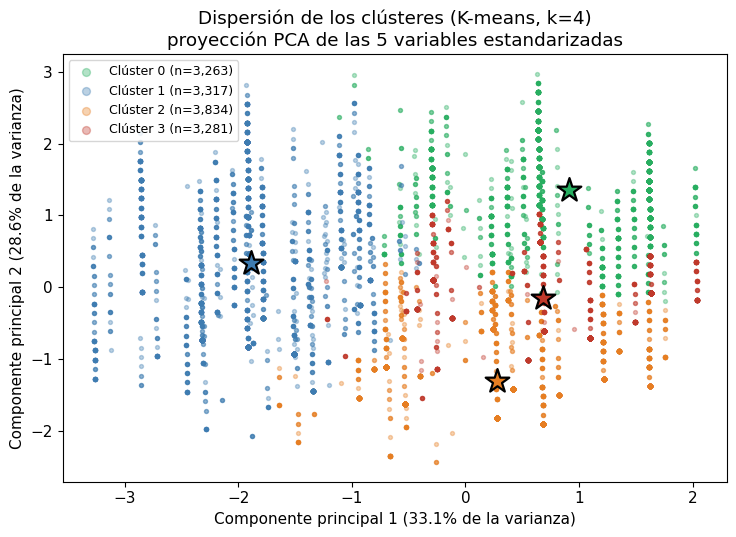

Varianza explicada por los dos componentes: 61.7%


In [30]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster)
var_exp = pca.explained_variance_ratio_
etiquetas = data_cluster['cluster'].values
centroides = pd.DataFrame(X_pca).groupby(etiquetas).mean()

colores = ['#27AE60', '#3E7CB1', '#E67E22', '#C0392B']      # 0 = mejor rendimiento ... 3 = peor
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for c in range(K):
    mask = etiquetas == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.35, color=colores[c], label=f'Clúster {c} (n={mask.sum():,})')
    ax.scatter(centroides.loc[c, 0], centroides.loc[c, 1], s=320, color=colores[c], edgecolor='black',
               linewidth=1.6, marker='*', zorder=5)
ax.set_title('Dispersión de los clústeres (K-means, k=4)\nproyección PCA de las 5 variables estandarizadas')
ax.set_xlabel(f'Componente principal 1 ({var_exp[0] * 100:.1f}% de la varianza)')
ax.set_ylabel(f'Componente principal 2 ({var_exp[1] * 100:.1f}% de la varianza)')
ax.legend(loc='best', fontsize=9, markerscale=2)
guardar_figura('figura7_dispersion_clusters_pca.png')
print(f'Varianza explicada por los dos componentes: {var_exp.sum() * 100:.1f}%')

## 16. Exploración complementaria con datos de 2023 

Como respuesta a la limitación de contar con un solo año, se exploró la incorporación de los periodos 2023-01 y
2023-02.

In [31]:
def depurar_y_codificar(raw):
    # Aplica las mismas reglas de depuración y codificación (créditos 0-60, edad 15-65).
    d = raw.copy()
    d[col_credit] = pd.to_numeric(d[col_credit], errors='coerce')
    d = d[(d[col_credit] >= 0) & (d[col_credit] <= 60)]
    d['edad'] = pd.to_numeric(d['edad'], errors='coerce')
    d = d[(d['edad'] >= 15) & (d['edad'] <= 65)]
    return pd.DataFrame({
        'creditos_aprobados': d[col_credit],
        'edad': d['edad'],
        'recibe_tutorias': (d['RECIBE TUTORIAS INTEGRALES (ACADÉMICAS Y DE ACOMPAÑAMIENTO)'] == 'SI').astype(int),
        'sexo_masculino': d['SEXO'].astype(str).str.upper().str.startswith('M').astype(int),
        'tipo_colegio_cod': d['TIPO_COLEGIO'].map(mapa_colegio),
        'nivel_form_padre_cod': d['NIVEL_FORMACION_PADRE'].map(mapa_padres),
        'nivel_form_madre_cod': d['NIVEL_FORMACION_MADRE'].map(mapa_padres),
        'politica_cuota_texto': d['POLITICA_CUOTA'],
        'sede_texto': d['SEDE '],
        'periodo': d['fuente'],
    })


RUTA_2023 = DATA_DIR / 'estudiantes_2023_anonimizado.csv'
EXISTE_2023 = RUTA_2023.exists()
if not EXISTE_2023:
    print(f'Sección omitida: no se encontró {RUTA_2023}. No afecta al análisis principal.')
else:
    raw23 = pd.read_csv(RUTA_2023, usecols=COLUMNAS, low_memory=False)
    raw24 = pd.read_csv(RUTA_2024, usecols=COLUMNAS, low_memory=False)

    # Calidad de datos del periodo 2023-02
    r = raw23[raw23['fuente'] == '23-02'][col_credit]
    r = pd.to_numeric(r, errors='coerce')
    print(f'Periodo 2023-02: {int(r.isna().sum()):,} de {len(r):,} registros sin valor de créditos aprobados ({100 * r.isna().mean():.1f}%)')

    panel = pd.concat([depurar_y_codificar(raw23), depurar_y_codificar(raw24)], ignore_index=True)
    panel['sede_cod'] = panel['sede_texto'].astype('category').cat.codes.replace(-1, np.nan)
    panel['politica_cuota_cod'] = panel['politica_cuota_texto'].astype('category').cat.codes.replace(-1, np.nan)
    panel['indice_instruccion_padres'] = panel[['nivel_form_padre_cod', 'nivel_form_madre_cod']].mean(axis=1)
    print(f'\nPanel de cuatro periodos tras depurar: {len(panel):,} registros')
    print(pd.DataFrame({'registros': panel['periodo'].value_counts(),
                        'creditos_prom': panel.groupby('periodo')['creditos_aprobados'].mean().round(1)}).sort_index().to_string())

Periodo 2023-02: 19,905 de 24,268 registros sin valor de créditos aprobados (82.0%)

Panel de cuatro periodos tras depurar: 63,661 registros
         registros  creditos_prom
periodo                          
2024-01      19145           19.6
2024-02      22729            3.4
23-01        19264           20.2
23-02         2523            3.3


In [32]:
if EXISTE_2023:
    # --- Segmentación en el panel ---
    dc = panel.dropna(subset=cluster_vars)
    print(f'Casos completos para la segmentación (cuatro periodos): {len(dc):,} ({100 * len(dc) / len(panel):.1f}%)')

    Xc = StandardScaler().fit_transform(dc[cluster_vars])
    km4 = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(Xc)
    print(f'K-means (k=4) en el panel completo -> silueta = {silhouette_score(Xc, km4.labels_):.3f}')

    # El clustering jerárquico necesita memoria proporcional a n^2: se compara sobre una muestra común.
    muestra = dc.sample(n=8000, random_state=SEED)
    Xm = StandardScaler().fit_transform(muestra[cluster_vars])
    s_km = silhouette_score(Xm, KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(Xm).labels_)
    s_ag = silhouette_score(Xm, AgglomerativeClustering(n_clusters=4).fit(Xm).labels_)
    print(f'Comparación sobre una muestra de 8,000 registros: K-means = {s_km:.3f} | jerárquico = {s_ag:.3f}')

Casos completos para la segmentación (cuatro periodos): 25,296 (39.7%)


K-means (k=4) en el panel completo -> silueta = 0.334


Comparación sobre una muestra de 8,000 registros: K-means = 0.331 | jerárquico = 0.317


In [33]:
if EXISTE_2023:
    # --- Predicción en el panel (el periodo entra como variables indicadoras, no como escala ordinal) ---
    base_vars = ['tipo_colegio_cod', 'politica_cuota_cod', 'indice_instruccion_padres',
                 'recibe_tutorias', 'sexo_masculino', 'edad', 'sede_cod']
    dr = panel.dropna(subset=base_vars + ['creditos_aprobados']).reset_index(drop=True)
    dummies = pd.get_dummies(dr['periodo'], prefix='periodo', drop_first=True).astype(float)
    Xp = pd.concat([dr[base_vars], dummies], axis=1)
    yp = dr['creditos_aprobados']
    print(f'Registros para la predicción: {len(dr):,}')
    print('Distribución por periodo (%):')
    print((dr['periodo'].value_counts(normalize=True) * 100).round(1).to_string())

    Xtr, Xte, ytr, yte = train_test_split(Xp, yp, test_size=0.2, random_state=SEED)
    m1 = metricas(yte, LinearRegression().fit(Xtr, ytr).predict(Xte))
    m2 = metricas(yte, RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED).fit(Xtr, ytr).predict(Xte))
    display(pd.DataFrame({'Regresión lineal': m1, 'Random Forest': m2}).T.round(3))

Registros para la predicción: 25,296
Distribución por periodo (%):
periodo
2024-01    50.4
23-01      43.3
2024-02     3.7
23-02       2.5


,R2,RMSE,MAE
Regresión lineal,0.192,11.294,7.848
Random Forest,0.296,10.538,6.942


En 2023-02 la mayoría de los registros no tiene créditos aprobados, lo que desbalancea el panel. La segmentación mejora pero el desempeño predictivo de ambos modelos baja.